In [1]:
!pip install pingouin

I. Introduction

This project utilizes the U.S. Chroinic Disease Indicators (CDI) dataset to examine the distribution of diabetes prevalence across different demographic groups. Specifically, we are looking at how racial and ethnic identities correlate with health outcomes. The primary objective is to determine if certain populations face a disproportionate burden of disease, which is a critical inquiry for public health and nursing practice.

Research Question: Does the age-adjusted prevalence of diabetes among adults differ significantly across racial and ethnic groups in the United States based on 2022 data?

Statistical Hypothesis: 

* Null Hypothesis ($H_0$): There is no significant difference in the mean age-adjusted diabetes prevalence across the different racial and ethnic groups ($\mu_1 = \mu_2 = \dots = \mu_n$).

* Alternative Hypothesis ($H_a$): At least one racial or ethnic group has a mean age-adjusted diabetes prevalence that is significantly different from the others.

The dataset was filtered fo the most recent year (2022), focusing on 'Age-adjusted Prevalence' to ensure a standardized comparison across states with varying age distributions. A One-Way ANOVA will be performed to test these hypotheses, followed by a Turkey HSD pairwise comparison to identify specific group differences

II. Results and Interpretation

The ANOVA test was conducted to evaluate the null hypothesis that diabetes prevalence is uniform across racial and ethnic categories. The analysis yielded an F-statistic of 25.67 and a p-value ($p\_unc$) of $4.27 \times 10^{-23}$. Since the p-value is significantly lower than the alpha level of 0.05, we reject the null hypothesis in favor of the alternative hypothesis. This result provides strong statistical evidence that race and ethnicity are significant factors in diabetes prevalence in the U.S. 

The results indicate a clear disparity: the White, non-Hispanic group showed the lowest mean prevalence at 8.7%, whereas the Hawaiian or Pacific Islander group showed the highest mean prevalence at 20.0%, followed by the American Indian or Alaska Native group at 17.1%. The Tukey HSD test confirmed that the differences between the White population and every other racial/ethnic group are statistically significant. As a nursing student, these findings emphasize that clinical outreach and diabetes prevention programs must be strategically prioritized for minority communities to effectively address these severe health disparities. 

IV. Future Steps

While this study provides a clear snapshot of disparities based on race and ethnicitiy, there are several areas for further research:

* Longitudinal Analysis: Comparing this 2022 data with data from a decade ago to see if the gap between these groups is widening or closing in response to public health initiatives.

* Two-Way ANOVA: Investigating the interaction between Sex (Male/Female) and Race/Ethnicity to see if specific subgroups (e.g., Hispanic women vs. Hispanic men) face unique risks.

* Social Determinants Overlay: Analyzing the data alongside socioeconomic indicators like poverty levels and insurance coverage to determine how much of the disparity is driven by economic factors versus biological or cultural ones.

V. Reference

Centers for Disease Control and Prevention. (2022). U.S. Chronic Disease Indicators (CDI) [Data set]. Retrieved from U.S._Chronic_Disease_Indicators.csv.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

sns.set_theme(style="whitegrid")

In [27]:
df = pd.read_csv('U.S._Chronic_Disease_Indicators.csv')
df_filtered = df[
    (df['Topic'] == 'Diabetes') & 
    (df['Question'] == 'Diabetes among adults') & 
    (df['YearStart'] == 2022) & 
    (df['DataValueType'] == 'Age-adjusted Prevalence') & 
    (df['StratificationCategory1'] == 'Race/Ethnicity')
].copy()
df_clean = df_filtered.dropna(subset=['DataValue'])
df_filtered.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
1049,2022,2022,RI,Rhode Island,BRFSS,Diabetes,Diabetes among adults,NaN,%,Age-adjusted Prevalence,...,DIA,DIA01,NaN,AGEADJPREV,RACE,MRC,NaN,NaN,NaN,NaN
207742,2022,2022,CT,Connecticut,BRFSS,Diabetes,Diabetes among adults,NaN,%,Age-adjusted Prevalence,...,DIA,DIA01,NaN,AGEADJPREV,RACE,BLK,NaN,NaN,NaN,NaN
208345,2022,2022,AR,Arkansas,BRFSS,Diabetes,Diabetes among adults,NaN,%,Age-adjusted Prevalence,...,DIA,DIA01,NaN,AGEADJPREV,RACE,AIAN,NaN,NaN,NaN,NaN
261331,2022,2022,DC,District of Columbia,BRFSS,Diabetes,Diabetes among adults,NaN,%,Age-adjusted Prevalence,...,DIA,DIA01,NaN,AGEADJPREV,RACE,HIS,NaN,NaN,NaN,NaN
261512,2022,2022,HI,Hawaii,BRFSS,Diabetes,Diabetes among adults,NaN,%,Age-adjusted Prevalence,...,DIA,DIA01,NaN,AGEADJPREV,RACE,WHT,NaN,NaN,NaN,NaN


In [28]:
anova_table = pg.anova(data=df_clean, dv='DataValue', between='Stratification1', detailed=True)

print('############# Anova Table #############')
print(anova_table, '\n')

############# Anova Table #############
            Source           SS   DF          MS          F         p_unc  \
0  Stratification1  2000.457671    6  333.409612  25.674755  4.269484e-23   
1           Within  2882.868180  222   12.985893        NaN           NaN   

        np2  
0  0.409651  
1       NaN   



In [29]:
if anova_table['p_unc'][0] < 0.05:
    pairwise = pg.pairwise_tukey(data=df_clean, dv='DataValue', between='Stratification1')
    print('############# Pairwise Comparison ############')
    print(pairwise) 
else: 
    print("Failed to reject the null hypothesis: Average levels are not different across groups.")

############# Pairwise Comparison ############
                                                 A  \
0   American Indian or Alaska Native, non-Hispanic   
1   American Indian or Alaska Native, non-Hispanic   
2   American Indian or Alaska Native, non-Hispanic   
3   American Indian or Alaska Native, non-Hispanic   
4   American Indian or Alaska Native, non-Hispanic   
5   American Indian or Alaska Native, non-Hispanic   
6                              Asian, non-Hispanic   
7                              Asian, non-Hispanic   
8                              Asian, non-Hispanic   
9                              Asian, non-Hispanic   
10                             Asian, non-Hispanic   
11                             Black, non-Hispanic   
12                             Black, non-Hispanic   
13                             Black, non-Hispanic   
14                             Black, non-Hispanic   
15      Hawaiian or Pacific Islander, non-Hispanic   
16      Hawaiian or Pacific Islande

/var/folders/5v/6g0xydlj23q75glnyrzb6nz00000gn/T/ipykernel_44916/4115771892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DataValue", y="Stratification1", data=df_clean, palette='Set2')


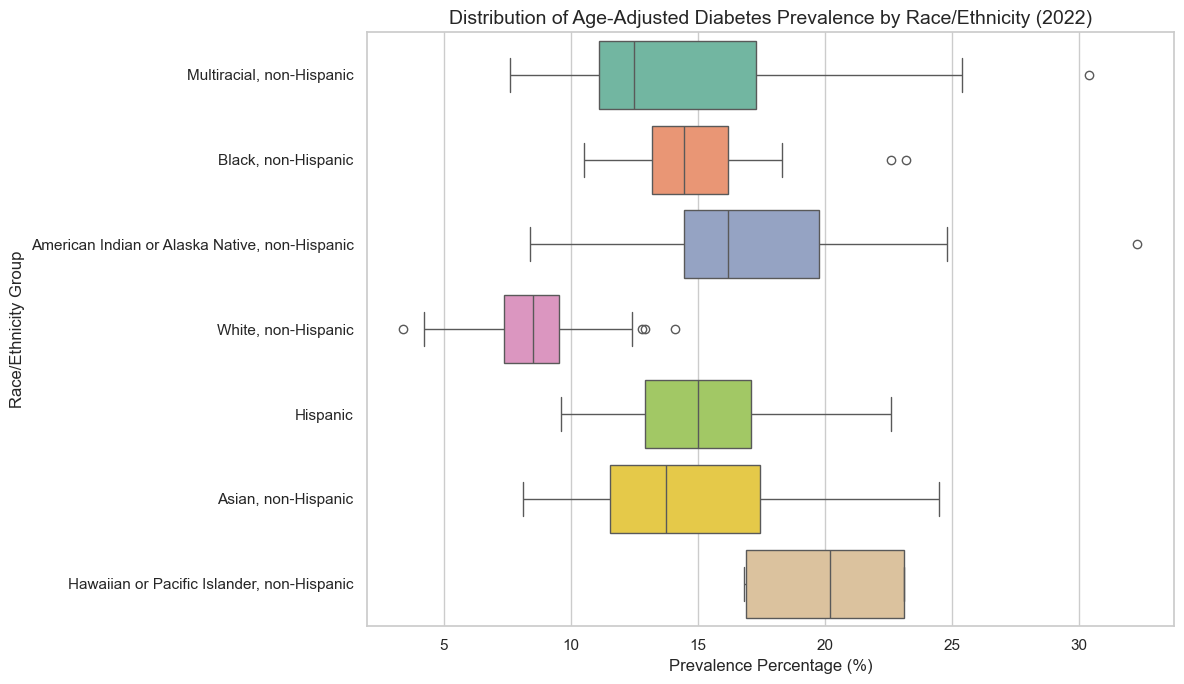

In [31]:
plt.figure(figsize=(12, 7))    
sns.boxplot(x="DataValue", y="Stratification1", data=df_clean, palette='Set2')

plt.title('Distribution of Age-Adjusted Diabetes Prevalence by Race/Ethnicity (2022)', fontsize=14)
plt.xlabel('Prevalence Percentage (%)', fontsize=12)
plt.ylabel('Race/Ethnicity Group', fontsize=12)
plt.tight_layout()
plt.show()